In [4]:
#Importando as bibliotecas padrãos
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Considerando o seguinte PVI:
$
\begin{cases}
y'(t) = 1 + (t - y)^2, & t \in [2, 4], \\
y(2) = 1.
\end{cases}
$

In [1]:
def f(t,y):
    return 1 + (t - y)**2

def real_f(t):
    return t - 1/(t - 1)

### Definições das Derivadas

As derivadas fornecidas no código podem ser representadas matematicamente como:

1. **Primeira Derivada:**
$$f'(t) = -2(t - y)^3$$

2. **Segunda Derivada:**
$$f''(t) = 6(t - y)^4$$

3. **Terceira Derivada:**
$$f'''(t) = -24(t - y)^5$$

In [2]:
def diff1(t,y):
  return -2*(t - y)**3

def diff2(t,y):
    return 6*(t - y)**4

def diff3(t,y):
    return -24*(t - y)**5

A norma L2 é escrita da seguinte forma:

$$\|e\|_2 = \sqrt{\sum_{i=1}^{n} |e_i|^2}$$


In [3]:
def erro_normaL2(y_real,y_aprox,h):
    return (h*np.cumsum((y_real - y_aprox)**2))**(1/2)

### Método de Taylor de Ordem 2

$$y_{n+1} = y_n + h f(t_n, y_n) + \frac{h^2}{2} f'(t_n, y_n)$$

Onde $f'(t, y)$ é a derivada total de $f$ em relação a $t$:
$$f'(t, y) = \frac{\partial f}{\partial t} + \frac{\partial f}{\partial y} f(t, y)$$

### Método de Heun

$$y_{n+1} = y_n + \frac{h}{2} \Big[ f(t_n, y_n) + f(t_n + h, y_n + h f(t_n, y_n)) \Big]$$

In [5]:
def taylor_2(y0, ti,tf,N,function):
    h = (tf - ti) / N
    t = np.zeros(N + 1)
    y = np.zeros(N + 1)
    y[0] = y0
    t[0] = ti
    for i in range(N):
        y[i + 1] = y[i] + function(t[i],y[i])*h + (diff1(t[i],y[i])*h**2)/2
        t[i + 1] = t[i] + h
    return t,y

def heun(y0,ti,tf,N,function):
    h = (tf - ti) / N
    y = np.zeros(N + 1)
    t = np.zeros(N + 1)
    t[0] = ti
    y[0] = y0
    for i in range(N):
        t[i  + 1] = t[i] + h
        k1 = function(t[i], y[i])
        y_m = y[i] + h*k1
        k2 = function(t[i + 1], y_m)
        k = (k1 + k2) / 2
        y[i + 1] = y[i] + h*k
    return t,y

Algorítmo que que roda os métodos para cada N enquanto a norma L2 for maior do que $10^{-4}$

In [6]:
errors_taylor = [1]
errors_heun = [1]
N_taylor = 1
N_heun = 1

while((errors_taylor[-1] >= 0.0001) & (errors_heun[-1] >= 0.0001)):
    t_taylor_2, y_taylor_2 = taylor_2(1,2,4,N_taylor,f)
    t_heun, y_heun = heun(1,2,4,N_heun,f)
    h_taylor = 2 / (N_taylor)
    h_heun = 2/(N_heun)
    errors_taylor.append(erro_normaL2(real_f(t_taylor_2),y_taylor_2,h_taylor)[-1])
    errors_heun.append(erro_normaL2(real_f(t_heun),y_heun,h_heun)[-1])
    N_taylor += 1
    N_heun += 1

while(errors_taylor[-1] >= 0.0001):
    h_taylor = 2 / (N_taylor)
    t_taylor_2, y_taylor_2 = taylor_2(1,2,4,N_taylor,f)
    errors_taylor.append(erro_normaL2(real_f(t_taylor_2),y_taylor_2,h_taylor)[-1])
    N_taylor += 1

while(errors_heun[-1] >= 0.0001):
    h_heun = 2 / (N_heun)
    t_heun, y_heun = heun(1,2,4,N_heun,f)
    errors_heun.append(erro_normaL2(real_f(t_heun),y_heun,h_heun)[-1])
    N_heun += 1


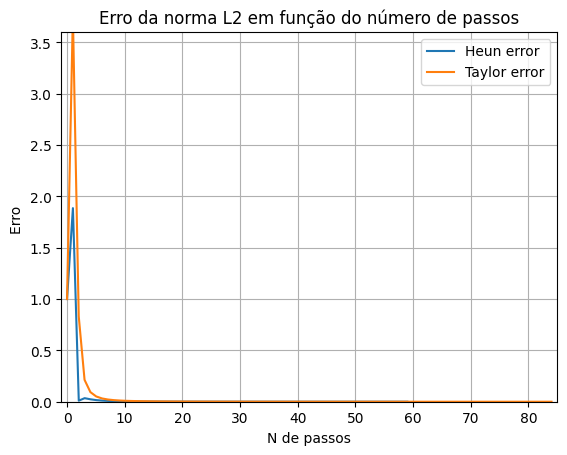

In [7]:
plt.plot(np.linspace(0,N_heun,len(errors_heun)),errors_heun, label = "Heun error")
plt.plot(np.linspace(0,N_taylor,len(errors_taylor)),errors_taylor , label = "Taylor error")
plt.grid()
plt.title("Erro da norma L2 em função do número de passos")
plt.xlabel("N de passos")
plt.ylabel("Erro ")
plt.axis([-1,85,0,3.6])
plt.legend()

Número de passos para que o erro seja menor que $10^{-4}$:

In [8]:
N_taylor2 = N_taylor
N_heun, N_taylor2

(59, 84)